## Generar espectros

In [2]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import pandas as pd
import os
import re
import gc
import warnings
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split

waves=np.loadtxt("waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

## load data

In [3]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations, including the non-contaminated case.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, including the
        non-contaminated case, with additional columns 'f_spot' and 'f_fac'.
    """
    df_list = []

    # Non-contaminated case: create a copy and add f_spot and f_fac as 0.0
    df_no_contam = df.copy()
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0
    # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
    cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    # Regular expression to extract f_spot and f_fac from the file name.
    # Expected pattern: fspot<value>_ffac<value>.txt
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verify that the file exists
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extract the file name and use the regex pattern to get f_spot and f_fac values
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Read contamination data from the file, ensuring it has at least 2 dimensions
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)
            # If there are at least two columns, take the second one; otherwise, flatten the array
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()
            # Check that the number of contamination values matches the expected n_points
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # Reverse the contamination values if needed (e.g., to match column order)
        contam_values = contam_values[::-1]

        # Create a copy of the original DataFrame for contamination application
        df_contam = df.copy()
        # Multiply the last n_points columns by the contamination values
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Add the contamination parameters as new columns
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        # Reorder columns to place the new parameters at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_contam.columns if col not in ["f_spot", "f_fac"]]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    # Concatenate all DataFrames into one final DataFrame
    df_final = pd.concat(df_list, ignore_index=True)
    # Define .data and .params attributes for later use
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [4]:
import pandas as pd

contamination_files = [
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.70.txt",
]


def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df

remove_warnings()

try:
    airless_data = pd.read_csv("spec_data/airless_data.csv")
    airless_data = apply_contaminations_from_files(contamination_files, airless_data, n_points)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data = apply_contaminations_from_files(contamination_files, CO2_data, n_points)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data = filter_rows(CH4_data)
    CH4_data = apply_contaminations_from_files(contamination_files, CH4_data, n_points)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data = pd.read_csv("spec_data/O3_data.csv")
    O3_data = filter_rows(O3_data)
    O3_data = apply_contaminations_from_files(contamination_files, O3_data, n_points)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data = filter_rows(H2O_data)
    H2O_data = apply_contaminations_from_files(contamination_files, H2O_data, n_points)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data = filter_rows(CH4_O3_data)
    CH4_O3_data = apply_contaminations_from_files(contamination_files, CH4_O3_data, n_points)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data = filter_rows(CH4_H2O_data)
    CH4_H2O_data = apply_contaminations_from_files(contamination_files, CH4_H2O_data, n_points)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data = filter_rows(O3_H2O_data)
    O3_H2O_data = apply_contaminations_from_files(contamination_files, O3_H2O_data, n_points)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data = filter_rows(CH4_O3_H2O_data)
    CH4_O3_H2O_data = apply_contaminations_from_files(contamination_files, CH4_O3_H2O_data, n_points)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_48976\2816719226.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_48976\2816719226.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_48976\2816719226.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

## Clean data

In [5]:
def mult_df(df, n_points, n_mult):
    """
    Duplicates the DataFrame n_mult+1 times with additional columns 'f_spot' and 'f_fac'
    set to 0.0. The final DataFrame has .data and .params attributes defined based on
    the last n_points columns.
    """
    df_list = []
    for _ in range(n_mult + 1):
        # Non-contaminated case
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final

In [6]:
import pandas as pd

def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df


try:
    airless_data_clean = pd.read_csv("spec_data/airless_data.csv")
    airless_data_clean = mult_df(airless_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data_clean = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data_clean = mult_df(CO2_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data_clean = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data_clean = filter_rows(CH4_data_clean)
    CH4_data_clean = mult_df(CH4_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data_clean = pd.read_csv("spec_data/O3_data.csv")
    O3_data_clean = filter_rows(O3_data_clean)
    O3_data_clean = mult_df(O3_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data_clean = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data_clean = filter_rows(H2O_data_clean)
    H2O_data_clean = mult_df(H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data_clean = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data_clean = filter_rows(CH4_O3_data_clean)
    CH4_O3_data_clean = mult_df(CH4_O3_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data_clean = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data_clean = filter_rows(CH4_H2O_data_clean)
    CH4_H2O_data_clean = mult_df(CH4_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data_clean = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data_clean = filter_rows(O3_H2O_data_clean)
    O3_H2O_data_clean = mult_df(O3_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data_clean = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data_clean = filter_rows(CH4_O3_H2O_data_clean)
    CH4_O3_H2O_data_clean = mult_df(CH4_O3_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [7]:
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

# Noise


In [8]:
import numpy as np
import pandas as pd
import warnings

def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Generates a new DataFrame by applying Gaussian noise to the spectra.

    Parameters:
        df: DataFrame with 'params' and 'data' attributes.
        n_repeat: Number of times each spectrum is replicated.
        noise_std: Scalar or 1D array for noise standard deviations. If length matches
                   number of wavelengths, interprets as per-wavelength noise. If length
                   matches number of spectra, interprets as per-spectrum noise. Otherwise
                   uses the mean value.
        seed: Seed for RNG (optional).

    Returns:
        DataFrame with replicated params and noisy spectra.
    """
    # Split params and spectra
    if hasattr(df, "params") and hasattr(df, "data"):
        df_params = df.params.reset_index(drop=True)
        df_spectra = df.data.reset_index(drop=True)
    else:
        raise ValueError("DataFrame must have 'params' and 'data' attributes.")
    
    n_rows, n_cols = df_spectra.shape

    # Determine noise type
    if np.isscalar(noise_std):
        print(f"Using scalar noise_std = {noise_std}")
        noise_vals = float(noise_std)
        noise_type = 'scalar'
    else:
        noise_array = np.array(noise_std, dtype=float)
        if noise_array.ndim != 1:
            warnings.warn("noise_std is not 1D; using mean value")
            noise_vals = noise_array.mean()
            noise_type = 'scalar'
        elif noise_array.shape[0] == n_cols:
            print("Using per-wavelength noise_std vector")
            noise_vals = noise_array
            noise_type = 'per_wavelength'
        elif noise_array.shape[0] == n_rows:
            print("Using per-spectrum noise_std vector")
            noise_vals = noise_array
            noise_type = 'per_spectrum'
        else:
            warnings.warn(
                "noise_std length does not match spectra rows or wavelengths; using mean value"
            )
            noise_vals = noise_array.mean()
            noise_type = 'scalar'
    
    # Set seed
    if seed is not None:
        np.random.seed(seed)

    # Replicate data
    df_spectra_rep = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns
    )
    df_params_rep = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns
    )

    # Build noise matrix
    if noise_type == 'scalar':
        noise_mat = np.full(df_spectra_rep.shape, noise_vals)
    elif noise_type == 'per_wavelength':
        noise_mat = np.tile(noise_vals, (n_rows * n_repeat, 1))
    else:  # per_spectrum
        # Expand per-row noise to match repeats and columns
        base = np.repeat(noise_vals[:, None], n_repeat, axis=1)
        noise_mat = np.tile(base, (1, n_cols)).reshape(n_rows * n_repeat, n_cols)

    # Apply noise
    noise = np.random.normal(0, noise_mat, df_spectra_rep.shape)
    df_spectra_rep += noise

    # Annotate params
    if noise_type == 'scalar':
        df_params_rep.insert(0, 'noise_std', noise_vals)
    elif noise_type == 'per_wavelength':
        df_params_rep.insert(0, 'noise_std', np.nan)
    else:
        df_params_rep.insert(0, 'noise_std', np.repeat(noise_vals, n_repeat))
    df_params_rep.insert(1, 'n_repeat', n_repeat)

    # Combine
    df_final = pd.concat([df_params_rep.reset_index(drop=True),
                          df_spectra_rep.reset_index(drop=True)], axis=1)
    # Set attributes
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -n_cols:]
    df_final.params = df_final.iloc[:, :-n_cols]
    warnings.filterwarnings("default")

    return df_final


## Data 

### FInal data

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


### Autoencoder 

In [ ]:
autoencoder = keras.models.load_model("Models/AE_l2.keras")

In [11]:
import numpy as np

def chi2(x, x_recon, sigma):
    """
    Calcula el estadístico χ² para cada muestra.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    
    Retorna
    -------
    chi2_vals : np.ndarray, shape (n_samples,)
        Valor de χ² para cada muestra.
    """
    return np.sum(((x - x_recon) / sigma)**2, axis=1)


def chi2_r(x, x_recon, sigma, p):
    """
    Calcula el estadístico χ² reducido para cada muestra,
    dado un número de parámetros p manual.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    p : int
        Número de grados de libertad "gastados".
    
    Retorna
    -------
    chi2_red : np.ndarray, shape (n_samples,)
        Valor de χ² reducido para cada muestra.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    N = x.shape[1]
    dof = N - p
    return chi2_vals / dof


def use_model_params(func):
    """
    Decorador que extrae p = nº de parámetros entrenables
    de un modelo Keras y lo pasa a la función chi2_r.
    """
    def wrapper(x, x_recon, sigma, model):
        p = model.count_params()
        return func(x, x_recon, sigma, p)
    return wrapper

@use_model_params
def chi2_r_params(x, x_recon, sigma, p):
    """
    Calcula χ² reducido usando p = nº de parámetros del modelo.
    
    Firma real tras aplicar decorador:
        chi2_r_params(x, x_recon, sigma, model)
    """
    return chi2_r(x, x_recon, sigma, p)


In [12]:
import os
import numpy as np
import pandexo.engine.justdoit as jdi
import matplotlib.pyplot as plt
import warnings

def get_pandexo_noise_from_file(file_path, n_transits, plot=False):
    """
    Reads a spectrum from a two-column file and returns PandExo error array.
    
    Parameters:
    -----------
    file_path : str
        Path to the spectrum file with two columns: wavelength (μm), flux.
    n_transits : int
        Number of transits for the PandExo simulation.
    plot : bool, optional
        If True, plots the spectrum with error bars.
        
    Returns:
    --------
    errors_trim : np.ndarray
        1D array of error_w_floor values (after trimming first 18 points).
    """
    # 1) Load spectrum
    data = np.loadtxt(file_path)
    waves = data[:, 0]
    flux  = data[:, 1]
    
    # 2) Configure PandExo dictionaries
    exo = jdi.load_exo_dict()
    exo["observation"].update({
        "sat_level": 80,
        "sat_unit": "%",
        "baseline_unit": "total",
        "baseline": 0.9535 * 3 * 60 * 60,
        "noise_floor": 0,
        "noccultations": n_transits,
    })
    exo["star"].update({
        "type": "phoenix",
        "mag": 11.354,
        "ref_wave": 1.25,
        "temp": 2566,
        "metal": 0.0,
        "logg": 5.2396,
    })
    exo["planet"].update({
        "type": "user",
        "w_unit": "um",
        "f_unit": "rp^2/r*^2",
        "transit_duration": 0.9535 * 60 * 60,
        "td_unit": "s",
        "exopath": file_path,
    })
    inst = jdi.load_mode_dict("NIRSpec Prism")
    inst["configuration"]["detector"].update({
        "subarray": "sub512",
        "ngroup": 6
    })
    
    # 3) Run PandExo and extract full spectrum
    results = jdi.run_pandexo(exo, inst)
    waves_full  = results["FinalSpectrum"]["wave"]
    flux_full   = results["FinalSpectrum"]["spectrum"]
    errors_full = results["FinalSpectrum"]["error_w_floor"]
    
    # 4) Trim first 18 points
    waves_trim  = waves_full[18:]
    flux_trim   = flux_full[18:]
    errors_trim = errors_full[18:]
    
    # 5) Plot with error bars if requested
    if plot:
        plt.figure(figsize=(8, 4))
        plt.errorbar(
            waves_trim, flux_trim,
            yerr=errors_trim,
            fmt='o', ms=4, elinewidth=1, capsize=2
        )
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Flux / Transit Depth")
        plt.title(f"PandExo Spectrum & Noise — {n_transits} Transits")
        plt.tight_layout()
        plt.show()
    
    return errors_trim

# Example usage:
# errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=10, plot=True)



Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]


End out of Transit
Starting In Transit Simulation
End In Transit


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


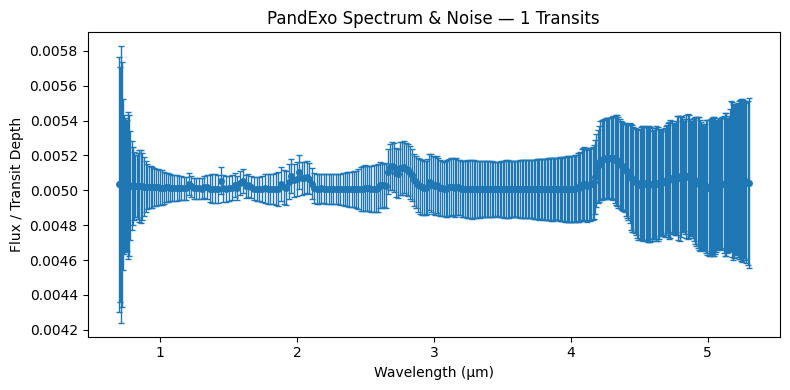

array([7.30712384e-04, 6.75766561e-04, 7.93531282e-04, 7.01703760e-04,
       4.90641106e-04, 3.99089072e-04, 3.82489967e-04, 3.75729423e-04,
       3.76316931e-04, 4.20132128e-04, 4.03325057e-04, 3.12289199e-04,
       2.55822499e-04, 2.22080605e-04, 1.93139986e-04, 1.77578129e-04,
       1.78418394e-04, 1.88780945e-04, 2.05955632e-04, 2.10548317e-04,
       1.92893712e-04, 1.69906130e-04, 1.46966475e-04, 1.28489769e-04,
       1.21141432e-04, 1.22307426e-04, 1.18158290e-04, 1.09288332e-04,
       1.04397569e-04, 1.02981215e-04, 1.02538167e-04, 9.89947520e-05,
       9.19888861e-05, 8.53863256e-05, 8.06350816e-05, 7.76111263e-05,
       7.63594351e-05, 7.53877702e-05, 7.26617782e-05, 6.98513896e-05,
       6.79817257e-05, 6.64680472e-05, 6.48786952e-05, 6.32712677e-05,
       6.21458954e-05, 6.13472608e-05, 6.00326110e-05, 5.89508025e-05,
       5.93284955e-05, 6.27473673e-05, 6.96841621e-05, 7.77818565e-05,
       8.38165960e-05, 8.35740712e-05, 7.95068501e-05, 7.71697886e-05,
      

In [13]:
errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=1, plot=True)

errors

Save Observation Spectrum to use in POSEIDON


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


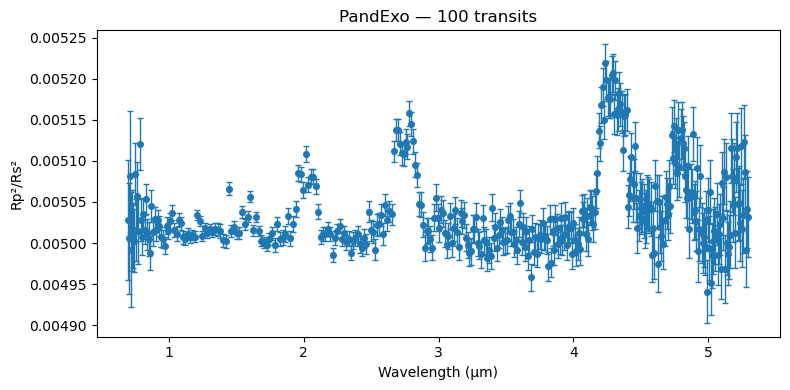

In [ ]:
""" ## Save SPECTRUM

import os
import numpy as np
import pandexo.engine.justdoit as jdi
import matplotlib.pyplot as plt

def save_pandexo_spectrum_to_dat(file_path, n_transits, output_dat, plot=False):
    """
    Corre PandExo y guarda en `output_dat` un archivo con columnas:
    wavelength (μm), wavelength_err (μm), spectrum_w_rand, error_w_floor.
    """
    # --- 1) Configurar PandExo ---
    exo = jdi.load_exo_dict()
    exo["observation"].update({
        "sat_level": 80,
        "sat_unit": "%",
        "baseline_unit": "total",
        "baseline": 0.9535 * 3 * 60 * 60,
        "noise_floor": 0,
        "noccultations": n_transits,
    })
    exo["star"].update({
        "type": "phoenix", "mag": 11.354, "ref_wave": 1.25,
        "temp": 2566, "metal": 0.0, "logg": 5.2396,
    })
    exo["planet"].update({
        "type": "user", "w_unit": "um", "f_unit": "rp^2/r*^2",
        "transit_duration": 0.9535 * 60 * 60, "td_unit": "s",
        "exopath": file_path,
    })
    inst = jdi.load_mode_dict("NIRSpec Prism")
    inst["configuration"]["detector"].update({
        "subarray": "sub512", "ngroup": 6
    })

    # --- 2) Ejecutar PandExo ---
    results = jdi.run_pandexo(exo, inst)  # :contentReference[oaicite:3]{index=3}
    fs = results["FinalSpectrum"]
    
    # --- 3) Recortar primeros 18 puntos ---
    waves_trim    = fs["wave"][18:]
    spec_rand_trim = fs["spectrum_w_rand"][18:]
    err_trim      = fs["error_w_floor"][18:]

    # --- 4) Calcular error en longitud de onda (aprox.) ---
    wave_err = np.gradient(waves_trim) / 2

    # --- 5) Guardar en .dat ---
    data_out = np.vstack([
        waves_trim,
        wave_err,
        spec_rand_trim,
        err_trim
    ]).T
    header = "wavelength(um)  wavelength_err(um)  spectrum_w_rand  error_w_floor"
    np.savetxt(output_dat, data_out, header=header, fmt="%.6e")

    # --- 6) Opcional: plotear ---
    if plot:
        plt.figure(figsize=(8,4))
        plt.errorbar(waves_trim, spec_rand_trim, 
                     xerr=wave_err, yerr=err_trim,
                     fmt='o', ms=4, elinewidth=1, capsize=2)
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Rp²/Rs²")
        plt.title(f"PandExo — {n_transits} transits")
        plt.tight_layout()
        plt.show()


save_pandexo_spectrum_to_dat(
    "pandexo_spec.txt", 
    n_transits=100, 
    output_dat="pandexo_output_100transits.dat", 
    plot=True
)
 """

## Evaluación del chi cuadrado reducido

In [13]:
# -*- coding: utf-8 -*-
# === UQ para Autoencoder (AE) — Versión SIMPLIFICADA ===
#
# 1) Incertidumbre ALEATORIA: Fija en 0.5 * Ruido Instrumental.
# 2) Incertidumbre EPISTÉMICA: MC Dropout Directo (Sin batches).
#

from __future__ import annotations

from typing import Optional, Tuple, Dict
import numpy as np
import pandas as pd
import tensorflow as tf

# Umbral para decidir si una fila (espectro) es “plana” (rango ~ 0).
EPS_RANGE = 1e-12

# ---------------------------------------------------------------------------
# 1) INCERTIDUMBRE ALEATORIA (Definición: 0.5 * Instrumental)
# ---------------------------------------------------------------------------
def calc_aleatoric_half_instrumental(
    sigma_inst: np.ndarray | float, 
    shape: Tuple[int, int],
    dtype=np.float32
) -> np.ndarray:
    """
    Calcula la incertidumbre aleatoria como exactamente la mitad del ruido instrumental.
    
    Fórmula: sigma_ale = 0.5 * sigma_inst
    """
    N, D = shape
    FACTOR = 0.5  # Requerimiento fijo
    
    # Aseguramos que sigma_inst sea array del tipo correcto
    if np.ndim(sigma_inst) == 0:
        # Caso: sigma_inst es un escalar único para todo
        s_val = float(sigma_inst)
        sig = np.full((N, D), s_val, dtype=dtype)
    else:
        # Caso: sigma_inst es un vector (D,) o matriz (N, D)
        s_vec = np.asarray(sigma_inst, dtype=dtype)
        
        if s_vec.ndim == 1:
            if s_vec.shape[0] != D:
                 raise ValueError(f"sigma_inst dim {s_vec.shape} no coincide con features D={D}")
            # Broadcasting (D,) -> (N, D)
            sig = np.tile(s_vec, (N, 1))
            
        elif s_vec.ndim == 2:
            if s_vec.shape != (N, D):
                raise ValueError(f"sigma_inst shape {s_vec.shape} no coincide con (N={N}, D={D})")
            sig = s_vec
        else:
            raise ValueError(f"Forma de sigma_inst no soportada: {s_vec.shape}")
            
    return (sig * FACTOR).astype(dtype)


# ---------------------------------------------------------------------------
# 2) INCERTIDUMBRE EPISTÉMICA (MC Dropout) — Anchor CLEAN (SIMPLIFICADA)
# ---------------------------------------------------------------------------
def mc_dropout_sigma_anchor_clean(
    autoencoder,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,      # se usa SOLO para DES-normalizar correctamente
    t_passes: int = 100,
    dtype=np.float32,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estima incertidumbre epistémica con MC Dropout: ejecuta T pasadas con `training=True`.
    Versión directa: pasa todo el dataset de una vez (sin batches manuales).
    """
    # --- 1) Normalización basada en el RUIDOSO (por fila) ---
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    N, D = x_noisy.shape
    x_min = x_noisy.min(axis=1, keepdims=True).astype(dtype)  # (N,1)
    x_max = x_noisy.max(axis=1, keepdims=True).astype(dtype)  # (N,1)
    x_rng = (x_max - x_min).astype(dtype)                     # (N,1)

    # `np.where` evita división por 0: si rango <= 0 → usa 1.0
    x_rng_safe = np.where(x_rng <= 0.0, 1.0, x_rng).astype(dtype)
    deg_noisy = (x_rng[:, 0] <= EPS_RANGE)

    x_norm = (x_noisy - x_min) / x_rng_safe
    if np.any(deg_noisy):
        x_norm[deg_noisy] = 0.0  # filas planas → vector de ceros

    # --- 2) Estadísticos del LIMPIO para DES-normalizar salidas ---
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)
    if x_clean.shape != (N, D):
        raise ValueError("x_clean_raw must match x_noisy_raw shape.")

    c_min = x_clean.min(axis=1, keepdims=True).astype(dtype)  # (N,1)
    c_max = x_clean.max(axis=1, keepdims=True).astype(dtype)  # (N,1)
    c_rng = (c_max - c_min).astype(dtype)                     # (N,1)
    deg_clean = (c_rng[:, 0] <= EPS_RANGE)

    # --- 3) T pasadas con dropout ACTIVO (training=True) ---
    outs_norm = []
    # Loop simple, sin batches
    for _ in range(int(t_passes)):
        # training=True activa dropout
        y = autoencoder(x_norm, training=True).numpy().astype(dtype, copy=False)
        outs_norm.append(y)
    
    outs_norm = np.stack(outs_norm, axis=0)  # (T, N, D)

    # --- 4) DES-normalizar con min/max del LIMPIO (anclaje clean) ---
    # Broadcasting: (T,N,D) * (N,1) → (T,N,D)
    outs = outs_norm * c_rng[None, :, :] + c_min[None, :, :]
    
    if np.any(deg_clean):
        # Filas planas en limpio → salida constante (c_min)
        outs[:, deg_clean, :] = c_min[deg_clean]
    
    del outs_norm

    # --- 5) Estadísticos en el eje T (pasadas MC) ---
    mean_dropout = outs.mean(axis=0).astype(dtype)                # (N,D)
    sigma_epi = outs.std(axis=0, ddof=1).astype(dtype)            # (N,D)
    
    del outs

    return mean_dropout, sigma_epi


# ---------------------------------------------------------------------------
# 3) COMBINACIÓN Y UTILIDADES
# ---------------------------------------------------------------------------
def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype=np.float32,
) -> np.ndarray:
    """
    Combina incertidumbres en cuadratura.
    sigma_total = sqrt(sigma_ale^2 + sigma_epi^2 + sigma_sys^2)
    """
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 += np.asarray(sigma_epi, dtype=dtype) ** 2
    if sigma_sys is not None:
        sig2 += np.asarray(sigma_sys, dtype=dtype) ** 2
        
    sigma_total = np.sqrt(sig2, dtype=dtype)
    
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
        
    return sigma_total


def coverage_metrics(y_true: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sigma = np.asarray(sigma)
    # Evitar división por cero
    sigma = np.where(sigma <= 0.0, np.finfo(sigma.dtype).eps, sigma)
    
    z = (y_true - y_pred) / sigma
    z_abs = np.abs(z)
    return {
        "coverage_1sigma": float(np.mean(z_abs <= 1.0)),
        "coverage_2sigma": float(np.mean(z_abs <= 2.0)),
    }


def sigma_comparison_summary(
    sigma_inst: np.ndarray,   
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray,
) -> Dict[str, float]:
    N, D = sigma_ale.shape
    # Broadcast de sigma_inst para métricas si es vector
    sigma_inst2 = (
        np.broadcast_to(sigma_inst[None, :], (N, D))
        if sigma_inst.ndim == 1 else sigma_inst
    )

    def _flat(a):
        a = np.asarray(a, dtype=np.float64).ravel()
        return a[np.isfinite(a)]

    def _med_ratio(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m == 0: return np.nan
        return float(np.median(a1[:m] / np.clip(b1[:m], 1e-12, np.inf)))

    def _corr(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m < 2: return np.nan
        return float(np.corrcoef(a1[:m], b1[:m])[0, 1])

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst2),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst2),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst2),
        "corr_epi_vs_inst": _corr(sigma_epi, sigma_inst2),
    }

In [24]:
# === Cell 2 (corregida) ===
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd

# ---------------- Parámetros ----------------
N_TRANSITS = 10
# MONTE_CARLO_REPEATS = 300  <-- Ya no se usa para input perturbation
T_PASSES_DROPOUT = 300
EPS_SIGMA = 1e-12
LATENT_DIM = 300
factor = 10 / 8

# -------------- Ruido instrumental -----------
errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=N_TRANSITS, plot=False)
errors = errors[::-1]
noise = errors  # alias

# -------------- Construcción de datasets -----
n_co2 = int(2500)
n_ch4 = int(250 * factor)
n_o3  = int(250 * factor)
n_h2o = int(250 * factor)
n_ch4_o3 = int(25 * factor * factor)
n_ch4_h2o = int(25 * factor * factor)
n_o3_h2o  = int(25 * factor * factor)
n_ch4_o3_h2o = int(2 * factor * factor * factor)
n_airless = int(100 * 3)

df_noisy = pd.concat(
    [
        #generate_df_with_noise_std(O3_H2O_data, n_o3_h2o, noise),
        #generate_df_with_noise_std(CH4_H2O_data, n_ch4_h2o, noise),
        #generate_df_with_noise_std(CH4_O3_data, n_ch4_o3, noise),
        #generate_df_with_noise_std(H2O_data, n_h2o, noise),
        #generate_df_with_noise_std(O3_data, n_o3, noise),
        #generate_df_with_noise_std(CH4_data, n_ch4, noise),
        #generate_df_with_noise_std(CO2_data, n_co2, noise),
        generate_df_with_noise_std(CH4_O3_H2O_data, n_ch4_o3_h2o, noise),
        generate_df_with_noise_std(airless_data, n_airless, noise),
    ], ignore_index=True,
)
df_clean = pd.concat(
    [
        #generate_df_with_noise_std(O3_H2O_data_clean, n_o3_h2o, 0),
        #generate_df_with_noise_std(CH4_H2O_data_clean, n_ch4_h2o, 0),
        #generate_df_with_noise_std(CH4_O3_data_clean, n_ch4_o3, 0),
        #generate_df_with_noise_std(H2O_data_clean, n_h2o, 0),
        #generate_df_with_noise_std(O3_data_clean, n_o3, 0),
        #generate_df_with_noise_std(CH4_data_clean, n_ch4, 0),
        #generate_df_with_noise_std(CO2_data_clean, n_co2, 0),
        generate_df_with_noise_std(CH4_O3_H2O_data_clean, n_ch4_o3_h2o, 0),
        generate_df_with_noise_std(airless_data_clean, n_airless, 0),
    ], ignore_index=True,
)

# -------------- Señales (últimas n_points columnas) --------------
X_noisy_raw = df_noisy.iloc[:, -n_points:]
X_clean_raw = df_clean.iloc[:, -n_points:]

# -------------- CÁLCULO DE INCERTIDUMBRES (LÓGICA ACTUALIZADA) --------------

# 1) Aleatoria: Heurística directa (0.5 * error instrumental)
sigma_ale = calc_aleatoric_half_instrumental(
    sigma_inst=errors, 
    shape=X_noisy_raw.shape,
    dtype=np.float32
)

# 2) Epistémica + Media: MC Dropout (Directo/Simplificado)
mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
    autoencoder=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw,
    t_passes=T_PASSES_DROPOUT,
    dtype=np.float32,
)

# 3) Combinación
recon_mean = mean_dropout  # La media viene del dropout
sigma_total = combine_uncertainties(
    sigma_ale=sigma_ale, 
    sigma_epi=sigma_epi, 
    floor=EPS_SIGMA, 
    dtype=np.float32
)

# -------------- Guardado --------------
np.savez("dae_uq_outputs.npz",
         recon_mean=recon_mean, sigma_ale=sigma_ale, sigma_epi=sigma_epi, sigma_total=sigma_total)
print(">>> Saved: dae_uq_outputs.npz")

# -------------- χ² consistentes -----------------------------------
try:
    # (A) Obs vs Recon con σ_inst (explicar observación)
    chi2_obs     = chi2(X_noisy_raw.values, recon_mean, errors)
    chi2r_obs_p0 = chi2_r(X_noisy_raw.values, recon_mean, errors, p=0)
    # (B) Clean vs Recon con σ_total (chequeo predictivo del limpio)
    sigT = np.clip(sigma_total, EPS_SIGMA, np.inf)
    chi2_clean_tot     = chi2(X_clean_raw.values, recon_mean, sigT)
    chi2r_clean_tot_p0 = chi2_r(X_clean_raw.values, recon_mean, sigT, p=0)

    print(f">>> Results for {N_TRANSITS} transits <<<")
    print("== Obs - Recon con σ_inst ==")
    print(f"mean χ²_r (p=0): {np.mean(chi2r_obs_p0):.4f}")
    print("\n== Clean - Recon con σ_total ==")
    print(f"mean χ²_r (p=0): {np.mean(chi2r_clean_tot_p0):.4f}")
except NameError:
    print("Aviso: chi2/chi2_r no están definidas; omite esta sección o impórtalas.")

# -------------- Comparación + Coverage ----------------------------
cmp_stats = sigma_comparison_summary(
    sigma_inst=errors, sigma_ale=sigma_ale, sigma_epi=sigma_epi, sigma_total=sigma_total
)
print("\n== Sigma comparison ==")
for k, v in cmp_stats.items():
    print(f"{k:>22}: {v:.4f}")

cov_obs = coverage_metrics(X_noisy_raw.values, recon_mean, errors)
cov_tot = coverage_metrics(X_clean_raw.values, recon_mean, np.clip(sigma_total, EPS_SIGMA, np.inf))
print("\n== Coverage ==")
print(f"Obs-Rec c/ σ_inst : 68%={cov_obs['coverage_1sigma']:.3f}  95%={cov_obs['coverage_2sigma']:.3f}")
print(f"Clean-Rec c/ σ_tot: 68%={cov_tot['coverage_1sigma']:.3f}  95%={cov_tot['coverage_2sigma']:.3f}")

Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 0\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Using per-wavelength noise_std vector
Using per-wavelength noise_std vector
Using scalar noise_std = 0
Using scalar noise_std = 0
>>> Saved: dae_uq_outputs.npz
>>> Results for 10 transits <<<
== Obs - Recon con σ_inst ==
mean χ²_r (p=0): 45.1050

== Clean - Recon con σ_total ==
mean χ²_r (p=0): 0.1756

== Sigma comparison ==
 med_ratio_ale_vs_inst: 0.5000
 med_ratio_epi_vs_inst: 0.1236
 med_ratio_tot_vs_inst: 0.5151
      corr_epi_vs_inst: 0.0102

== Coverage ==
Obs-Rec c/ σ_inst : 68%=0.230  95%=0.398
Clean-Rec c/ σ_tot: 68%=0.962  95%=0.996


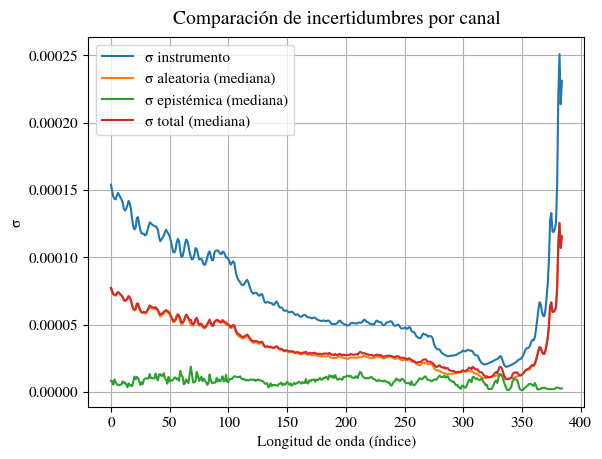

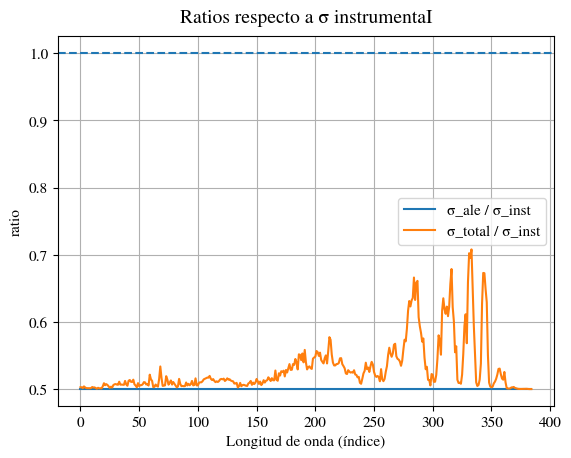


== Coverage (fracción de puntos) ==
Instrumental:  68%=0.988  95%=0.999
Aleatoria:     68%=0.940  95%=0.988
Total (A+E):   68%=0.962  95%=0.996


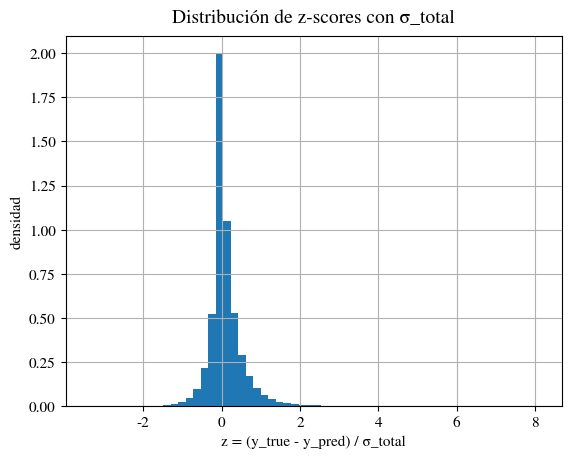


Guardado: C:\Proyectos\Astro\AEspectra\exp 0\sigma_summary.csv


In [25]:
# === Plots & resumen de incertidumbres ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _as_ndarray(x):
    if isinstance(x, (pd.DataFrame, pd.Series)):
        return x.values
    return np.asarray(x)

def _broadcast_sigma_inst(sigma_inst, N, D):
    s = _as_ndarray(sigma_inst)
    if s.ndim == 1:
        if s.shape[0] != D:
            raise ValueError(f"len(sigma_inst)={s.shape[0]} != D={D}")
        sD = s
        sND = np.broadcast_to(s[None, :], (N, D))
    elif s.ndim == 2:
        if s.shape != (N, D):
            raise ValueError(f"sigma_inst shape {s.shape} ≠ (N,D)=({N},{D})")
        sND = s
        sD = s.mean(axis=0)
    else:
        raise ValueError("sigma_inst debe ser (D,) o (N,D)")
    return sD, sND

def _coverage(y_true, y_pred, sigma):
    y_true = _as_ndarray(y_true)
    y_pred = _as_ndarray(y_pred)
    sigma  = _as_ndarray(sigma)
    sigma  = np.where(sigma <= 0, np.finfo(float).eps, sigma)
    z = (y_true - y_pred) / sigma
    z = z[np.isfinite(z)]
    if z.size == 0:
        return np.nan, np.nan, z
    cov1 = float(np.mean(np.abs(z) <= 1.0))
    cov2 = float(np.mean(np.abs(z) <= 2.0))
    return cov1, cov2, z

# ----------- Recolecta variables del entorno -----------
sigma_ale   = _as_ndarray(sigma_ale)         # (N,D)
sigma_epi   = _as_ndarray(sigma_epi)         # (N,D)
sigma_total = _as_ndarray(sigma_total)       # (N,D)
N, D = sigma_ale.shape

sigma_inst_var = errors if 'errors' in globals() else noise   # (D,) o (N,D)
sigma_inst_D, sigma_inst_ND = _broadcast_sigma_inst(sigma_inst_var, N, D)

wl = _as_ndarray(wavelengths) if 'wavelengths' in globals() else np.arange(D)
if wl.shape[0] != D: wl = np.arange(D)

# ----------- Resúmenes por longitud de onda -----------
sigma_ale_med = np.median(sigma_ale, axis=0)
sigma_epi_med = np.median(sigma_epi, axis=0)
sigma_tot_med = np.median(sigma_total, axis=0)
eps = 1e-12
ratio_ale_inst = sigma_ale_med / np.clip(sigma_inst_D, eps, None)
ratio_tot_inst = sigma_tot_med / np.clip(sigma_inst_D, eps, None)

# ----------- Plot 1: σ por canal -----------
plt.figure()
plt.plot(wl, sigma_inst_D, label="σ instrumento")
plt.plot(wl, sigma_ale_med, label="σ aleatoria (mediana)")
plt.plot(wl, sigma_epi_med, label="σ epistémica (mediana)")
plt.plot(wl, sigma_tot_med, label="σ total (mediana)")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("σ")
plt.title("Comparación de incertidumbres por canal")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Plot 2: Ratios vs instrumento -----------
plt.figure()
plt.plot(wl, ratio_ale_inst, label="σ_ale / σ_inst")
plt.plot(wl, ratio_tot_inst, label="σ_total / σ_inst")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("ratio")
plt.title("Ratios respecto a σ instrumentaI")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Coverage + histograma de z (si hay y_true/y_pred) ------
if 'recon_mean' in globals() and 'X_clean_raw' in globals():
    y_pred = _as_ndarray(recon_mean)          # (N,D)
    y_true = _as_ndarray(X_clean_raw)         # (N,D)
    cov1_i, cov2_i, z_i = _coverage(y_true, y_pred, sigma_inst_ND)
    cov1_a, cov2_a, z_a = _coverage(y_true, y_pred, sigma_ale)
    cov1_t, cov2_t, z_t = _coverage(y_true, y_pred, sigma_total)

    print("\n== Coverage (fracción de puntos) ==")
    print(f"Instrumental:  68%={cov1_i:.3f}  95%={cov2_i:.3f}")
    print(f"Aleatoria:     68%={cov1_a:.3f}  95%={cov2_a:.3f}")
    print(f"Total (A+E):   68%={cov1_t:.3f}  95%={cov2_t:.3f}")

    plt.figure()
    plt.hist(z_t, bins=60, density=True)
    plt.xlabel("z = (y_true - y_pred) / σ_total")
    plt.ylabel("densidad")
    plt.title("Distribución de z-scores con σ_total")
    plt.grid(True)
    plt.show()

# ----------- CSV resumen por longitud de onda -----------
summary = pd.DataFrame({
    "lambda": wl if wl.ndim == 1 else np.arange(D),
    "sigma_inst": sigma_inst_D,
    "sigma_ale_med": sigma_ale_med,
    "sigma_epi_med": sigma_epi_med,
    "sigma_total_med": sigma_tot_med,
    "ratio_ale_inst": ratio_ale_inst,
    "ratio_total_inst": ratio_tot_inst,
})
summary_path = Path("sigma_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"\nGuardado: {summary_path.resolve()}")


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral", "DejaVu Serif", "Times New Roman", "CMU Serif", "Liberation Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["axes.titlesize"]    = 14
mpl.rcParams["axes.titleweight"]  = "normal"
mpl.rcParams["axes.titlepad"]     = 10
mpl.rcParams["figure.titlesize"]  = 16
mpl.rcParams["figure.titleweight"] = "normal"


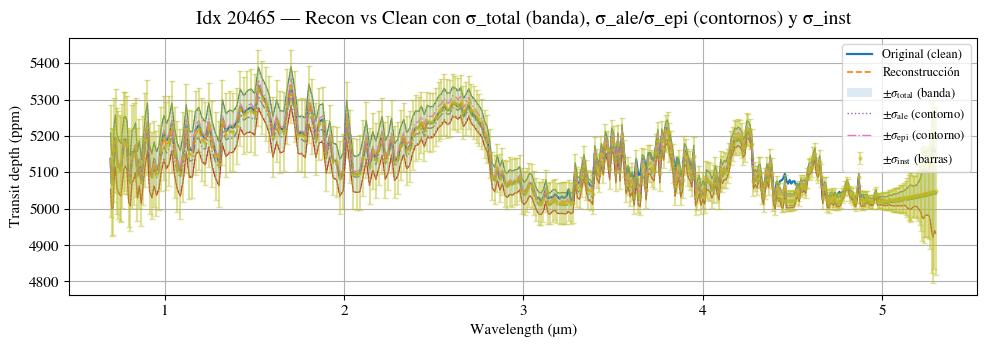

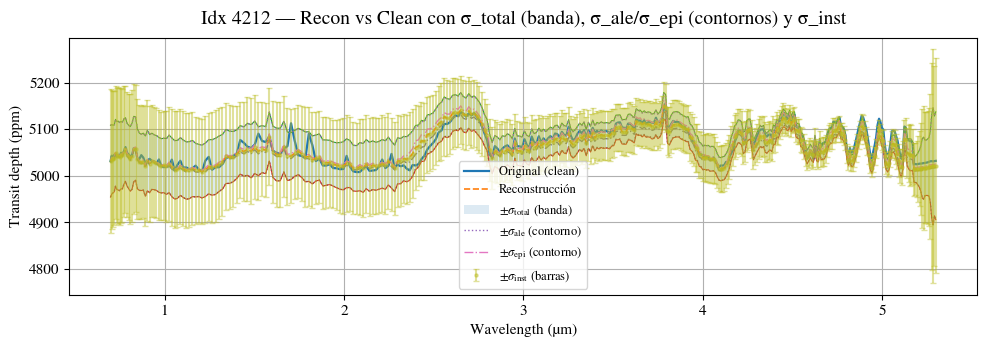

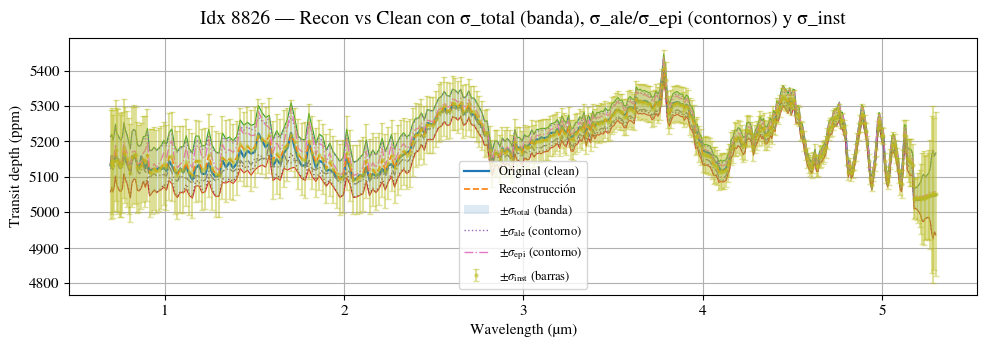

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _as_nd(x):
    import pandas as pd
    if isinstance(x, (pd.DataFrame, pd.Series)): return x.values
    return np.asarray(x)

def _per_sample_sigma(s, i, N, D):
    s = _as_nd(s)
    if s.ndim == 1:
        if s.shape[0] != D: raise ValueError(f"sigma length {s.shape[0]} != D={D}")
        return s
    elif s.ndim == 2:
        if s.shape != (N, D): raise ValueError(f"sigma shape {s.shape} != (N,D)=({N},{D})")
        return s[i]
    raise ValueError("sigma must be (D,) or (N,D)")

# ---------- función principal ----------
def plot_four_sigmas_singlepanel(indices=None, n_random=3, rng_seed=None, ppm=True,
                                 waves_key="wavelengths", show_inst=True,
                                 lw_lines=1.0, lw_edges=0.8, alpha_total=0.15):
    """
    Un panel por espectro:
      - línea clean
      - línea recon
      - banda ±σ_total con borde
      - contornos ±σ_ale y ±σ_epi
      - (opcional) barras ±σ_inst sobre la recon
    """
    # variables requeridas del entorno
    Yc   = _as_nd(X_clean_raw)
    Yr   = _as_nd(recon_mean)
    sig_inst = errors
    sig_ale  = sigma_ale
    sig_epi  = sigma_epi
    sig_tot  = sigma_total

    N, D = Yr.shape

    # eje x
    if waves_key in globals():
        wl = _as_nd(globals()[waves_key])
    elif "waves" in globals():
        wl = _as_nd(globals()["waves"])
    else:
        wl = np.arange(D)
    if wl.shape[0] != D:
        wl = np.arange(D)

    # índices
    rng = np.random.default_rng(rng_seed)
    if indices is None:
        n_random = min(n_random, N)
        idxs = rng.choice(N, size=n_random, replace=False)
    else:
        idxs = np.asarray(indices, dtype=int)

    # escala
    scale = 1e6 if ppm else 1.0
    unit  = "ppm" if ppm else "arb."

    for i in idxs:
        y_clean = Yc[i]
        y_recon = Yr[i]
        s_inst_i = _per_sample_sigma(sig_inst, i, N, D)
        s_ale_i  = _per_sample_sigma(sig_ale,  i, N, D)
        s_epi_i  = _per_sample_sigma(sig_epi,  i, N, D)
        s_tot_i  = _per_sample_sigma(sig_tot,  i, N, D)

        y_clean_p = y_clean * scale
        y_recon_p = y_recon * scale
        s_inst_p  = s_inst_i * scale
        s_ale_p   = s_ale_i  * scale
        s_epi_p   = s_epi_i  * scale
        s_tot_p   = s_tot_i  * scale

        plt.figure(figsize=(10, 3.6))

        # 1) líneas clean & recon
        plt.plot(wl, y_clean_p, lw=1.6, label="Original (clean)")
        plt.plot(wl, y_recon_p, lw=1.2, linestyle="--", label="Reconstrucción")

        # 2) banda ±σ_total con borde
        band = plt.fill_between(wl, y_recon_p - s_tot_p, y_recon_p + s_tot_p,
                                alpha=alpha_total, label=r"±$\sigma_{\rm total}$ (banda)")
        # bordes explícitos de la banda (para que “el shadow tenga borde”)
        plt.plot(wl, y_recon_p + s_tot_p, lw=lw_edges)
        plt.plot(wl, y_recon_p - s_tot_p, lw=lw_edges)

        # 3) contornos ±σ_ale (líneas más finas)
        plt.plot(wl, y_recon_p + s_ale_p, lw=lw_lines, linestyle=":", label=r"±$\sigma_{\rm ale}$ (contorno)")
        plt.plot(wl, y_recon_p - s_ale_p, lw=lw_lines, linestyle=":")

        # 4) contornos ±σ_epi (líneas finas, estilo distinto)
        plt.plot(wl, y_recon_p + s_epi_p, lw=lw_lines, linestyle="-.", label=r"±$\sigma_{\rm epi}$ (contorno)")
        plt.plot(wl, y_recon_p - s_epi_p, lw=lw_lines, linestyle="-.")

        # 5) barras ±σ_inst sobre la recon (referencia de escala)
        if show_inst:
            plt.errorbar(wl, y_recon_p, yerr=s_inst_p, fmt='o', ms=2.2, capsize=2,
                         alpha=0.45, label=r"±$\sigma_{\rm inst}$ (barras)")

        plt.xlabel("Wavelength (µm)" if wl.dtype.kind != 'i' else "Channel index")
        plt.ylabel(f"Transit depth ({unit})")
        plt.title(f"Idx {i} — Recon vs Clean con σ_total (banda), σ_ale/σ_epi (contornos){' y σ_inst' if show_inst else ''}")
        plt.legend(loc="best", fontsize=9, frameon=True)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# ===== Ejemplos =====
# Tres índices aleatorios, mostrando los cuatro sigmas
plot_four_sigmas_singlepanel(n_random=3,  ppm=True)

# Índices fijos
# plot_four_sigmas_singlepanel(indices=[1000, 2000], ppm=True)


In [28]:
df_noisy[df_noisy["atm CO2"] != 0.00]


,noise_std,n_repeat,f_spot,f_fac,Unnamed: 0,sma,seed,p_radius,p_mass,p_seed,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.004927,0.004939,0.004913,0.004958,0.005069,0.005274,0.005263,0.004681,0.005117,0.005020
1,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.004993,0.005036,0.004761,0.005135,0.004863,0.004681,0.005499,0.005393,0.004979,0.004376
2,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.005053,0.004911,0.005203,0.004928,0.005051,0.005147,0.004947,0.004985,0.005015,0.004719
3,NaN,3,0.0,0.0,667,0.02925,NaN,0.92,0.692,NaN,...,0.004930,0.005055,0.005188,0.005022,0.005073,0.005007,0.004994,0.004979,0.004964,0.005046
4,NaN,3,0.0,0.0,667,0.02925,NaN,0.92,0.692,NaN,...,0.004887,0.005204,0.005123,0.004938,0.004879,0.004995,0.005090,0.005217,0.004826,0.005272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46075,NaN,3,0.26,0.7,2998,0.02925,NaN,0.92,0.692,NaN,...,0.003462,0.004023,0.003582,0.003834,0.004947,0.004413,0.004238,0.003901,0.004218,0.004963
46076,NaN,3,0.26,0.7,2998,0.02925,NaN,0.92,0.692,NaN,...,0.003525,0.003835,0.003451,0.003824,0.004887,0.004386,0.004511,0.004121,0.004694,0.004469
46077,NaN,3,0.26,0.7,2999,0.02925,NaN,0.92,0.692,NaN,...,0.003558,0.004141,0.003935,0.003817,0.005080,0.004224,0.004250,0.004445,0.004711,0.004960
46078,NaN,3,0.26,0.7,2999,0.02925,NaN,0.92,0.692,NaN,...,0.003345,0.004242,0.003632,0.003689,0.005083,0.004364,0.004478,0.004206,0.004478,0.004702


In [29]:
df_noisy[
    #(df_noisy["atm CO2"] == 0) &
    (df_noisy["atm CH4"] == -6) &
    (df_noisy["atm O3"] == -5) &
    (df_noisy["atm H2O"] == -5) &
    (df_noisy["f_spot"] == 0) &
    (df_noisy["f_fac"] == 0)
]


,noise_std,n_repeat,f_spot,f_fac,Unnamed: 0,sma,seed,p_radius,p_mass,p_seed,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
1395,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.005089,0.004898,0.004986,0.005001,0.005038,0.004670,0.005196,0.004996,0.005046,0.004883
1396,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.005044,0.005080,0.005032,0.004867,0.005290,0.005029,0.004922,0.005393,0.004927,0.004465
1397,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.004742,0.005025,0.004860,0.005154,0.005159,0.004855,0.005142,0.005166,0.005303,0.004966
1398,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.004996,0.005126,0.005101,0.005029,0.005258,0.005110,0.004987,0.005595,0.005312,0.004894
1399,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.005136,0.005098,0.004894,0.005030,0.004869,0.005005,0.005108,0.004514,0.004797,0.004855
1400,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.004871,0.005068,0.005028,0.004917,0.004923,0.005156,0.004923,0.005186,0.004911,0.005032
1401,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.005140,0.005109,0.004859,0.005029,0.005149,0.004988,0.005236,0.005170,0.005366,0.005247
1402,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.004905,0.005146,0.004811,0.005256,0.004959,0.005304,0.005331,0.005087,0.004756,0.005431
1403,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.005008,0.005135,0.005262,0.005280,0.005065,0.005056,0.004864,0.004763,0.004808,0.005239


C:\Users\User\AppData\Local\Temp\ipykernel_57004\2960606982.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


>>> Plot guardado: plots/exp0-final_style-instrumental_uq-10Transit.png


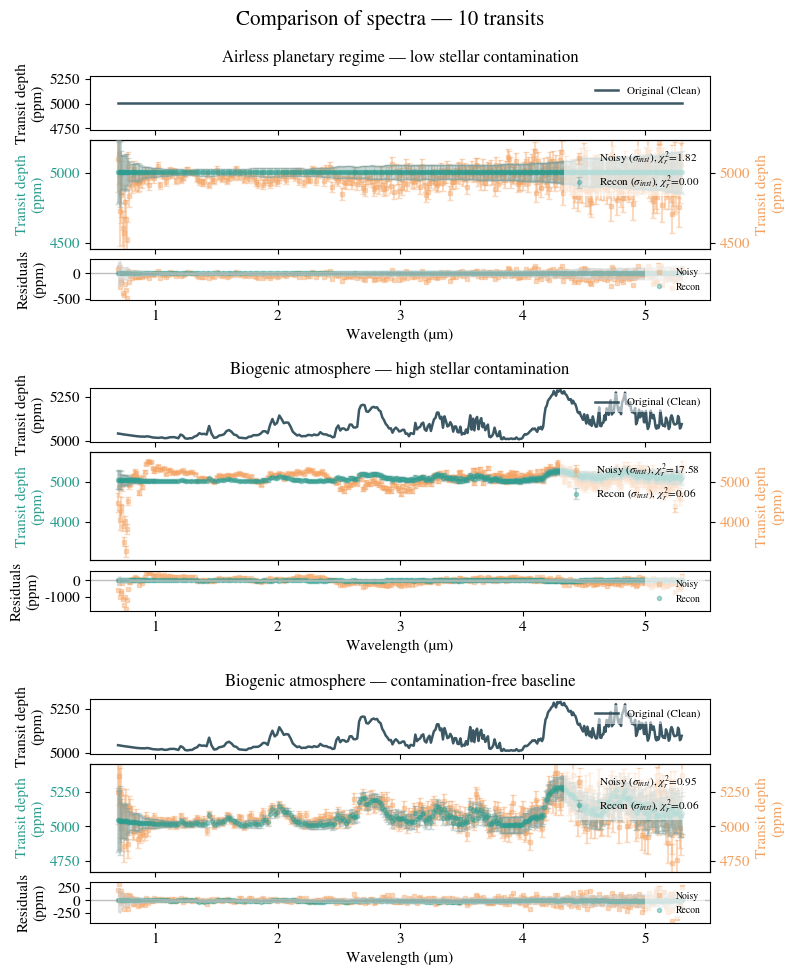

>>> Plot guardado: plots/exp0-final_style-total_uq-10Transit.png


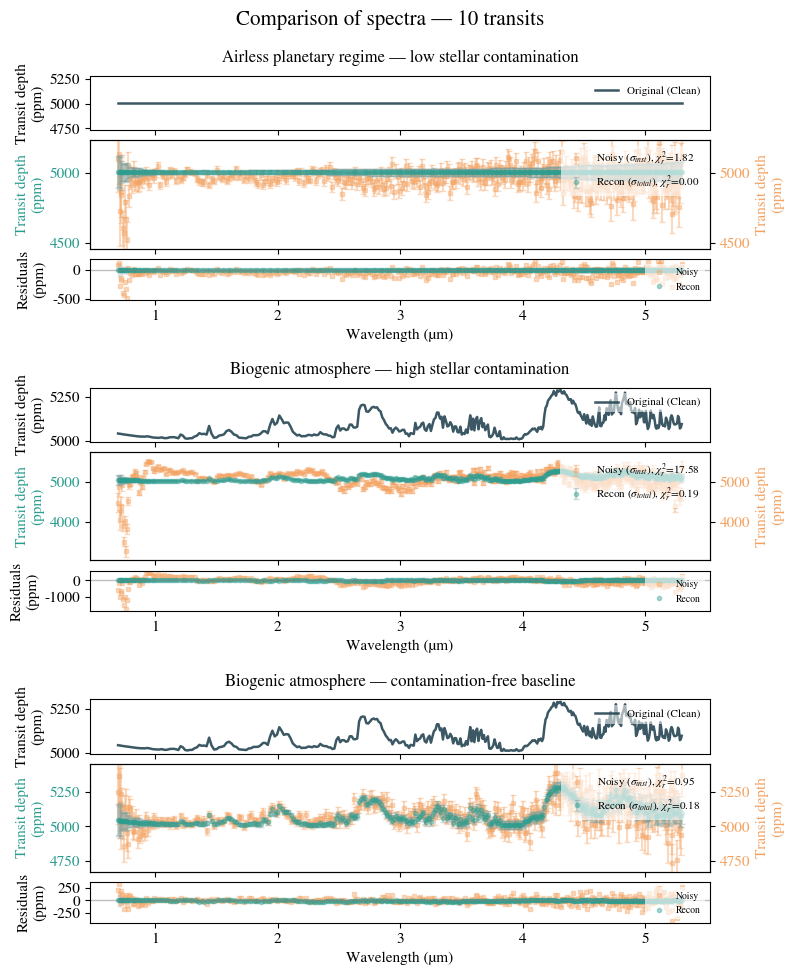

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
import os  # <--- Necesario para crear la carpeta

# --- 1. Carga de Datos ---
try:
    y_recon_all = recon_mean
    sigma_total_all = sigma_total
    y_clean_all = X_clean_raw.values
    y_noisy_all = X_noisy_raw.values
    sigma_inst = errors
    waves_i = waves[::-1] # Ojo: Asegúrate que 'waves' existe
except NameError as e:
    print(f"Error: Variable faltante: {e}")
    # raise  # Descomenta si quieres que pare aquí

# --- 2. Función para crear el plot ---
def create_plot_with_your_style(uncertainty_type: str):
    # --- Configuración ---
    colors = {
        'original':      '#264653',
        'reconstructed': '#2A9D8F',
        'noisy_points':  '#F4A261',
        'fill_uq_resid': '#cccccc80'
    }
    idx_list = [46677, 42873, 1401] # Asegúrate que estos índices existen en tu N
    custom_titles = [
        "Airless planetary regime — low stellar contamination",
        "Biogenic atmosphere — high stellar contamination",
        "Biogenic atmosphere — contamination-free baseline"
    ]
    plt.rcParams.update({'font.size': 11})

    n_groups = len(idx_list)
    spacer = 2.5
    height_ratios = [val for i in range(n_groups) for val in ([2, 4, 1.5] + ([spacer] if i < n_groups - 1 else []))]

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    for i, idx in enumerate(idx_list):
        base = 4 * i
        ax_orig   = fig.add_subplot(gs[base])
        ax_mix    = fig.add_subplot(gs[base + 1], sharex=ax_orig)
        ax_resid  = fig.add_subplot(gs[base + 2], sharex=ax_orig)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        # --- Datos ---
        y_clean, y_noisy, y_recon = y_clean_all[idx], y_noisy_all[idx], y_recon_all[idx]

        if uncertainty_type == 'instrumental':
            sigma_recon = sigma_inst
            recon_sigma_label = r'\sigma_{inst}'
        else:
            sigma_recon = sigma_total_all[idx]
            recon_sigma_label = r'\sigma_{total}'

        # Cálculo Chi2 (asumiendo que chi2_r existe globalmente)
        chi2r_n = chi2_r(y_clean[None, :], y_noisy[None, :], sigma_inst, p=0)[0]
        chi2r_recon = chi2_r(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]

        y_clean_ppm, y_noisy_ppm, y_recon_ppm = y_clean*1e6, y_noisy*1e6, y_recon*1e6
        sigma_inst_ppm, sigma_recon_ppm = sigma_inst*1e6, sigma_recon*1e6

        # --- Panel 1: Original ---
        ax_orig.plot(waves_i, y_clean_ppm, color=colors['original'], lw=1.8, alpha=0.9, label='Original (Clean)')
        ax_orig.set_ylabel("Transit depth\n(ppm)")
        ax_orig.set_title(custom_titles[i], fontsize=12)
        leg1 = ax_orig.legend(fontsize=8, loc='upper right', frameon=True, fancybox=True,
                              facecolor='white', edgecolor='none', framealpha=0.55)
        leg1.set_zorder(1000)
        
        # --- Panel 2: Mix (Twin Axes) ---
        ax_mix_r = ax_mix.twinx()

        # Corrección Formato Ejes
        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax_orig.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3); ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0); ax_mix_r.patch.set_alpha(0.0)
        
        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors['reconstructed'])
        ax_mix.tick_params(axis='y', labelcolor=colors['reconstructed'])
        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors['noisy_points'])
        ax_mix_r.tick_params(axis='y', labelcolor=colors['noisy_points'])
        
        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_n:.2f}"
        ax_mix_r.errorbar(waves_i, y_noisy_ppm, yerr=sigma_inst_ppm, color=colors['noisy_points'],
                          fmt='s', capsize=2, alpha=0.4, ms=3, label=noisy_label, zorder=8)
        
        recon_label = rf"Recon (${recon_sigma_label}$), $\chi^2_r$={chi2r_recon:.2f}"
        ax_mix.errorbar(waves_i, y_recon_ppm, yerr=sigma_recon_ppm, color=colors['reconstructed'],
                        fmt='o', capsize=2, alpha=0.4, ms=3, label=recon_label, ecolor='#85A39F', zorder=9)
        
        # --- CRÍTICO: Sincronizar límites Y para evitar ilusión óptica ---
        # Como usas twinx, matplotlib escala independiente. Forzamos que sean iguales.
        # Calculamos el rango total que abarca todo (ruido y recon)
        all_vals = np.concatenate([y_noisy_ppm, y_recon_ppm])
        y_min, y_max = all_vals.min(), all_vals.max()
        margin = (y_max - y_min) * 0.1 # 10% margen
        ax_mix.set_ylim(y_min - margin, y_max + margin)
        ax_mix_r.set_ylim(y_min - margin, y_max + margin)
        # ---------------------------------------------------------------

        lines1, labels1 = ax_mix.get_legend_handles_labels()
        lines2, labels2 = ax_mix_r.get_legend_handles_labels()
        leg2 = ax_mix.legend(lines2 + lines1, labels2 + labels1, fontsize=8, loc='upper right',
                             frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)
        leg2.set_zorder(1000)

        # --- Panel 3: Residuals ---
        resid_n = (y_noisy - y_clean) * 1e6
        resid_r = (y_recon - y_clean) * 1e6
        
        if uncertainty_type == 'instrumental':
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=5, label=None)
        else:
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=0,)
        
        ax_resid.plot(waves_i, resid_n, 's', color=colors['noisy_points'], alpha=0.4, ms=3, label='Noisy', zorder=1)
        ax_resid.plot(waves_i, resid_r, 'o', color=colors['reconstructed'], alpha=0.4, ms=3, label='Recon', zorder=2)

        ax_resid.axhline(0, color='gray', lw=1, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)
        ax_resid.legend(fontsize=7, loc='upper right', 
         frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)

    # --- Título y guardado ---
    supt_title = f"Comparison of spectra — {N_TRANSITS} transits"
    fig.suptitle(supt_title, fontsize=15, y=0.94)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # --- SEGURIDAD: Crear carpeta si no existe ---
    os.makedirs("plots", exist_ok=True) 
    # ---------------------------------------------

    filename = f"plots/exp0-final_style-{uncertainty_type}_uq-{N_TRANSITS}Transit"
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    # plt.savefig(f"{filename}.svg", bbox_inches='tight') # Opcional
    print(f">>> Plot guardado: {filename}.png")
    
    plt.show()

# --- 3. Ejecutar ---
create_plot_with_your_style(uncertainty_type='instrumental')
create_plot_with_your_style(uncertainty_type='total')

# Análisis por contaminación estelar y SNR

In [14]:
import pandas as pd

def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df


try:
    airless_data_clean = pd.read_csv("spec_data/airless_data.csv")
    airless_data_clean = mult_df(airless_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data_clean = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data_clean = mult_df(CO2_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data_clean = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data_clean = filter_rows(CH4_data_clean)
    CH4_data_clean = mult_df(CH4_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data_clean = pd.read_csv("spec_data/O3_data.csv")
    O3_data_clean = filter_rows(O3_data_clean)
    O3_data_clean = mult_df(O3_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data_clean = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data_clean = filter_rows(H2O_data_clean)
    H2O_data_clean = mult_df(H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data_clean = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data_clean = filter_rows(CH4_O3_data_clean)
    CH4_O3_data_clean = mult_df(CH4_O3_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data_clean = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data_clean = filter_rows(CH4_H2O_data_clean)
    CH4_H2O_data_clean = mult_df(CH4_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data_clean = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data_clean = filter_rows(O3_H2O_data_clean)
    O3_H2O_data_clean = mult_df(O3_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data_clean = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data_clean = filter_rows(CH4_O3_H2O_data_clean)
    CH4_O3_H2O_data_clean = mult_df(CH4_O3_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_48976\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle

# ===========================================================
# CONFIG / CONSTANTES (ajusta los valores como en tu script)
# ===========================================================
N_TRANSITS_LIST = [1, 2, 3, 5, 7, 10,15,20]

f_spot_values = [0, 0.01, 0.08, 0.26]
f_fac_values  = [0, 0.08, 0.54, 0.70]
factor        = 10 / 8

MONTE_CARLO_REPEATS = 1000   # input-noise MC (aleatoria)
T_PASSES_DROPOUT    = 100    # MC Dropout (epistémica)
EPS_SIGMA           = 1e-12  # piso numérico para sigma_total

# n_points = 288  # ya deberías tenerlo definido antes

# ===========================================================
# FUNCIONES AUXILIARES (asegúrate que existan/importadas)
# ===========================================================
# - get_pandexo_noise_from_file(...)
# - generate_df_with_noise_std(...)
# - chi2_r(...)
# - mc_reconstruct_mean_std_full_anchor_clean(...)
# - mc_dropout_sigma_anchor_clean(...)
# - combine_uncertainties(...)
# - autoencoder (ya cargado)
# - CH4_O3_H2O_data, airless_data,
#   CH4_O3_H2O_data_clean, airless_data_clean

def filtrar_data(df, f_spot_val, f_fac_val):
    """Subset matching the stellar heterogeneity pair."""
    return df[(df["f_spot"] == f_spot_val) & (df["f_fac"] == f_fac_val)]

# ===========================================================
# CONSTRUIR DATASET LIMPIO MAESTRO (una sola vez)
# ===========================================================
print("Building master CLEAN dataset (one-time)...")
n_ch4_o3_h2o_maestro = int(2 * factor * factor * factor)
n_airless_maestro    = int(100 * 3)

df_clean_maestro = pd.concat(
    [
        generate_df_with_noise_std(CH4_O3_H2O_data_clean, n_ch4_o3_h2o_maestro, 0),
        generate_df_with_noise_std(airless_data_clean,    n_airless_maestro,    0),
    ],
    ignore_index=True,
)
print("Master CLEAN dataset ready. ✅")

# ===========================================================
# CONTENEDORES DE RESULTADOS
# ===========================================================
# 1) Agregados por (f_spot, f_fac, n_transits) — como antes
all_results = {}

# ===========================================================
# BUCLE PRINCIPAL
# ===========================================================
print("\nStarting sensitivity & UQ analysis...")

for f_spot_val in f_spot_values:
    for f_fac_val in f_fac_values:
        # Sólo procesar (0,0) o pares donde ambos son no-cero
        if (f_spot_val == 0) ^ (f_fac_val == 0):
            continue

        # --- Agregados por este par (f_spot, f_fac) ---
        scores = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        # Para este combo usamos el dataset limpio maestro completo
        df_clean_filtered = df_clean_maestro

        desc = f"Processing f_spot={f_spot_val}, f_fac={f_fac_val}"
        for nt in tqdm(N_TRANSITS_LIST, desc=desc, leave=True):

            # 1) Ruido instrumental para este n_transits (vector por λ)
            instrumental_noise = get_pandexo_noise_from_file(
                "pandexo_spec.txt", n_transits=nt, plot=False
            )
            instrumental_noise = instrumental_noise[::-1]
            instrumental_noise = np.asarray(instrumental_noise, dtype=np.float32)
            if instrumental_noise.ndim != 1:
                raise ValueError("Expected 1D instrumental noise vector per wavelength.")

            # 2) Construir dataset RUIDOSO
            df_noisy = pd.concat(
                [
                    generate_df_with_noise_std(
                        CH4_O3_H2O_data, n_ch4_o3_h2o_maestro, instrumental_noise
                    ),
                    generate_df_with_noise_std(
                        airless_data,    n_airless_maestro,    instrumental_noise
                    ),
                ],
                ignore_index=True,
            )

            # 3) Filtrar por (f_spot, f_fac)
            df_noisy_filtered = filtrar_data(df_noisy, f_spot_val, f_fac_val)

            print(f"\n>> n_transits={nt}, f_spot={f_spot_val}, f_fac={f_fac_val}")
            print(f"   - Instrumental noise mean (scalar over λ): {instrumental_noise.mean():.6e}")
            print(f"   - # noisy samples: {df_noisy_filtered.shape[0]}")
            print(f"   - # clean samples: {df_clean_filtered.shape[0]}")

            if df_noisy_filtered.empty:
                # Agregados con NaN para mantener longitud
                scores["n_transits"].append(nt)
                scores["chi2r_noisy_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_total"].append(np.nan)

                nan_vec = np.full((n_points,), np.nan, dtype=np.float32)
                scores["sigma_inst_mean_lambda"].append(nan_vec.copy())
                scores["sigma_ale_mean_lambda"].append(nan_vec.copy())
                scores["sigma_epi_mean_lambda"].append(nan_vec.copy())
                scores["sigma_total_mean_lambda"].append(nan_vec.copy())

            # 4) Extraer bloques espectrales
            X_noisy_raw = df_noisy_filtered.iloc[:, -n_points:]
            X_clean_raw = df_clean_filtered.iloc[:, -n_points:]

            if X_noisy_raw.shape[0] != X_clean_raw.shape[0]:
                raise RuntimeError(
                    f"Row mismatch clean/noisy: {X_clean_raw.shape[0]} vs {X_noisy_raw.shape[0]}"
                )

            # 5) UQ: sigmas aleatoria, epistémica y total
            sigma_ale = calc_aleatoric_half_instrumental(
                sigma_inst=instrumental_noise, 
                shape=X_noisy_raw.shape,
                dtype=np.float32
            )

            # 2) Epistémica + Media: MC Dropout (Directo/Simplificado)
            mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=X_noisy_raw,
                x_clean_raw=X_clean_raw,
                t_passes=T_PASSES_DROPOUT,
                dtype=np.float32,
            )

            # 3) Combinación
            recon_mean = mean_dropout  # La media viene del dropout
            sigma_total = combine_uncertainties(
                sigma_ale=sigma_ale, 
                sigma_epi=sigma_epi, 
                floor=EPS_SIGMA, 
                dtype=np.float32
            )
            # 6) Medias por longitud de onda
            sigma_inst_mean_lambda  = instrumental_noise.astype(np.float32)        # [n_points]
            sigma_ale_mean_lambda   = np.nanmean(sigma_ale,  axis=0).astype(np.float32)
            sigma_epi_mean_lambda   = np.nanmean(sigma_epi,  axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total,axis=0).astype(np.float32)

            # 7) Chi-cuadrado reducido (puede devolver vector o escalar; lo normalizamos a np.array)
            chi2r_1 = np.asarray(
                chi2_r(X_clean_raw.values, X_noisy_raw.values, instrumental_noise, p=0),
                dtype=np.float32,
            )
            chi2r_2 = np.asarray(
                chi2_r(X_clean_raw.values, recon_mean, instrumental_noise, p=0),
                dtype=np.float32,
            )
            chi2r_3 = np.asarray(
                chi2_r(X_clean_raw.values, recon_mean, sigma_total, p=0),
                dtype=np.float32,
            )

            print(f"   - χ²_r (noisy vs clean | inst): {float(np.mean(chi2r_1)):.4f}")
            print(f"   - χ²_r (recon vs clean | inst): {float(np.mean(chi2r_2)):.4f}")
            print(f"   - χ²_r (recon vs clean | total): {float(np.mean(chi2r_3)):.4f}")

            # --- Guardar agregados ---
            scores["n_transits"].append(nt)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_1)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_2)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_3)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)

        # Al final de este par (f_spot, f_fac):
        all_results[(f_spot_val, f_fac_val)] = scores

print("\nDone! ✅")

# ===========================================================
# GUARDAR PKL
# ===========================================================
# 1) Agregado por n_transits (como antes)
output_filename = "results_by_transits_final.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(all_results, f)
print(f"Results saved to: '{output_filename}'")


Building master CLEAN dataset (one-time)...
Using scalar noise_std = 0
Using scalar noise_std = 0
Master CLEAN dataset ready. ✅

Starting sensitivity & UQ analysis...


Processing f_spot=0, f_fac=0:   0%|          | 0/8 [00:00<?, ?it/s]

Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
        Use "format" instead. [pandeia.engine.extinction]


Starting Out of Transit Simulation


...

Starting Out of Transit Simulation


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 0\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Using per-wavelength noise_std vector
Using per-wavelength noise_std vector

>> n_transits=20, f_spot=0.26, f_fac=0.7
   - Instrumental noise mean (scalar over λ): 4.889263e-05
   - # noisy samples: 4908
   - # clean samples: 4908


Processing f_spot=0.26, f_fac=0.7: 100%|██████████| 8/8 [02:16<00:00, 17.09s/it]

   - χ²_r (noisy vs clean | inst): 34.3403
   - χ²_r (recon vs clean | inst): 0.0746
   - χ²_r (recon vs clean | total): 0.1476

Done! ✅
Results saved to: 'results_by_transits_final.pkl'


In [58]:
all_results

{(0, 0): {'n_transits': [1, 2, 4, 6, 13, 20, 37, 100],
  'chi2r_noisy_clean_inst': [1.0009704245433224,
   0.9997829009614433,
   1.001463075739669,
   0.9999727282231241,
   1.002319491217233,
   0.9999240115255802,
   1.0001680570081484,
   1.0002950110549116],
  'chi2r_recon_clean_inst': [0.10377612198730563,
   0.1017281006221159,
   0.09698357103674034,
   0.09501722306077648,
   0.1101573197104047,
   0.11950182495648094,
   0.14090949820431667,
   0.23540786495677296],
  'chi2r_recon_clean_total': [0.36418262752394304,
   0.33548536415782115,
   0.28500854232773504,
   0.2551448438064632,
   0.24090064038696898,
   0.22635457496919886,
   0.2058008080139729,
   0.20250037573491567],
  'sigma_inst_mean_lambda': [array([4.86710720e-04, 4.71397710e-04, 4.58670838e-04, 4.53699700e-04,
          4.52235545e-04, 4.60679876e-04, 4.67641221e-04, 4.62302327e-04,
          4.56833834e-04, 4.52098204e-04, 4.43764322e-04, 4.30366752e-04,
          4.26012586e-04, 4.30048531e-04, 4.38260497e

# Plot

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_48976\3107654910.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')


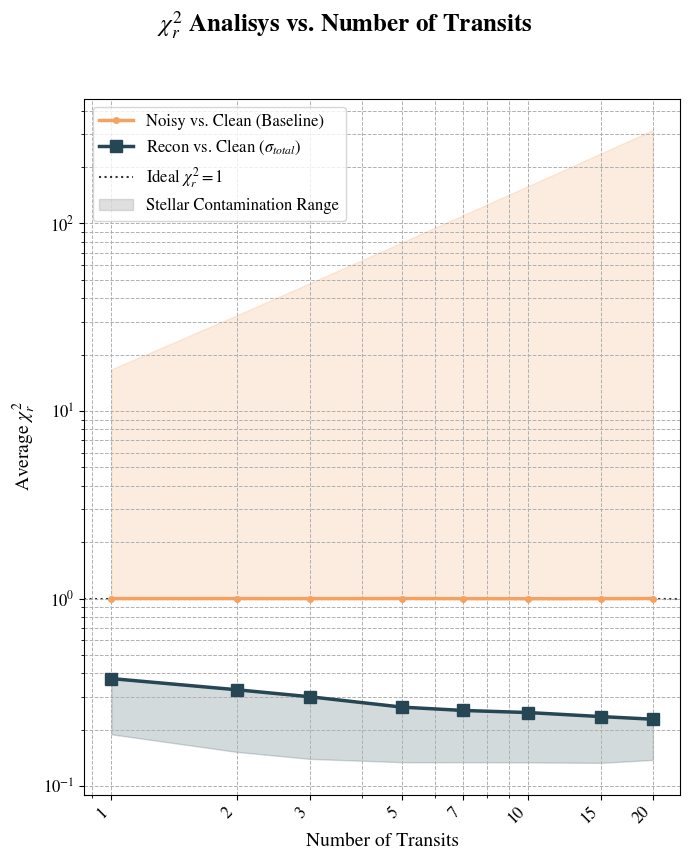

In [31]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# ============================
# Cargar Resultados
# ============================
filename = 'results_by_transits_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(f"Archivo '{filename}' no encontrado. Asegúrate de que el script de cálculo se haya ejecutado y el archivo esté en la misma carpeta.")

# Verificar que el caso base (sin contaminación) existe
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("No se encontraron datos para el caso base (f_spot=0, f_fac=0).")

# Extraer los valores del eje X
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Configuración de Plots
# ============================
# <<< CORRECCIÓN: Se cambiaron los nombres de las métricas para que coincidan con el archivo .pkl
# Se reemplazó '_vs_clean_' por '_clean_'.
metrics = [
    'chi2r_noisy_clean_inst',
    #'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total'
]

# Etiquetas para la leyenda del gráfico
labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    #'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# Paleta de colores y marcadores para cada métrica
palette_colors = ["#F4A261", "#2A9D8F", "#264653", "#E9C46A", "#E76F51"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    #'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    #'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def get_min_max(metric, transit_list, results_dict):
    """Calcula el rango min/max en todos los escenarios de contaminación para el sombreado."""
    mins, maxs = [], []
    for nt in transit_list:
        vals = [data[metric][data['n_transits'].index(nt)] 
                for key, data in results_dict.items() 
                if nt in data['n_transits'] and np.isfinite(data[metric][data['n_transits'].index(nt)])]
        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)
    return np.array(mins), np.array(maxs)

# ============================
# Crear el Gráfico Unificado
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7,9))

fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')

# Iterar sobre las métricas para plotearlas en el mismo eje
for metric in metrics:
    line_col = palette[metric]

    # 1. Sombreado del rango (todos los casos de f_spot/f_fac)
    mn, mx = get_min_max(metric, transits_plot, all_results)
    ax.fill_between(x_vals, mn, mx, color=line_col, alpha=0.20)

    # 2. Línea principal del caso base (f_spot=0, f_fac=0)
    y_base = [case_base[metric][case_base['n_transits'].index(nt)] if nt in case_base['n_transits'] else np.nan for nt in transits_plot]
    ax.plot(x_vals, y_base, marker=markers[metric], markersize=8, color=line_col, lw=2.5, label=labels[metric])

# 3. Configuración de ejes, grilla y leyenda
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Línea de referencia en y=1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.8, zorder=0, label=r'Ideal $\chi^2_r = 1$')

# Forzar que todas las etiquetas aparezcan en la leyenda
handles, labels_ax = ax.get_legend_handles_labels()
# Añadir etiqueta para el área sombreada
handles.append(plt.Rectangle((0,0),1,1, color='gray', alpha=0.25))
labels_ax.append('Stellar Contamination Range')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best')

# Formato del eje X para que muestre números en lugar de notación científica
ax.set_xticks(transits_plot)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Guardar figura
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'chi2r_analysis.png'), dpi=300)
plt.savefig(os.path.join(output_dir, 'chi2r_analysis.svg'))
plt.show()

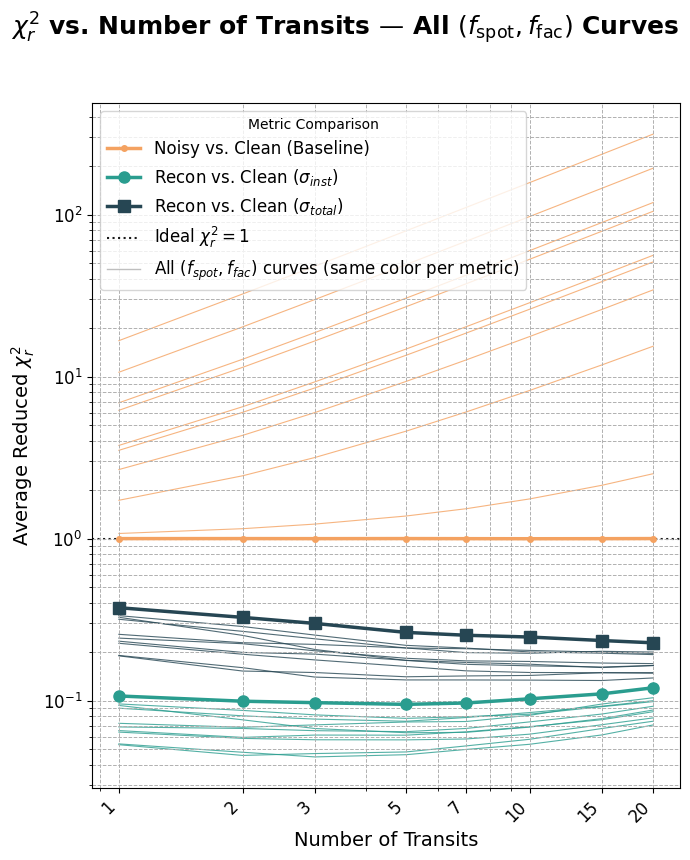

In [27]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ============================
# Load results
# ============================
filename = 'results_by_transits_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(
        f"File '{filename}' not found. Make sure the compute script ran "
        "and the file is in the same folder."
    )

# Check the base (no contamination) exists
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case (f_spot=0, f_fac=0) in results.")

# X axis (number of transits)
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Plot configuration
# ============================
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total',
]

labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# One color per metric; all contamination curves use the same color as their metric
palette_colors = ["#F4A261", "#2A9D8F", "#264653"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def series_for_metric_at_transits(data_dict, metric, transits_ref):
    """
    Return y-values for 'metric' aligned to transits_ref using the
    indexes from 'data_dict["n_transits"]'. Non-existing points -> np.nan.
    """
    ys = []
    t_list = data_dict.get('n_transits', [])
    for nt in transits_ref:
        if nt in t_list:
            idx = t_list.index(nt)
            val = data_dict[metric][idx]
        else:
            val = np.nan
        ys.append(val)
    return np.array(ys, dtype=float)

# ============================
# Make the unified plot
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7, 9))
fig.suptitle(r'$\chi^2_r$ vs. Number of Transits — All $(f_{\mathrm{spot}}, f_{\mathrm{fac}})$ Curves',
             fontsize=18, y=0.98, weight='bold')

# Draw all contamination curves (thin, semi-transparent) + highlight base case
for metric in metrics:
    color = palette[metric]

    # 1) All (f_spot, f_fac) scenarios (same color, thin lines)
    #    Skip the base key for this layer; we'll plot it thicker later.
    for key, data in all_results.items():
        if key == base_key:
            continue
        if metric not in data:
            continue
        y_vals = series_for_metric_at_transits(data, metric, transits_plot)

        # Plot only if we have at least two finite points
        finite = np.isfinite(y_vals)
        if np.count_nonzero(finite) >= 2:
            ax.plot(
                x_vals[finite],
                y_vals[finite],
                lw=0.8,
                alpha=0.8,
                color=color,
                zorder=1,
            )

    # 2) Base case (thicker, markers, on top)
    y_base = series_for_metric_at_transits(case_base, metric, transits_plot)
    finite_base = np.isfinite(y_base)
    if np.count_nonzero(finite_base) >= 2:
        ax.plot(
            x_vals[finite_base],
            y_base[finite_base],
            marker=markers[metric],
            markersize=8,
            color=color,
            lw=2.5,
            label=labels[metric],
            zorder=3,
        )

# Axes, grid, legend
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average Reduced $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Reference line at y = 1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.9, zorder=0,
           label=r'Ideal $\chi^2_r = 1$')

# Legend: add a proxy thin line for "All contamination curves"
from matplotlib.lines import Line2D
proxy = Line2D([0], [0], lw=1.0, alpha=0.5, color='gray')
handles, labels_ax = ax.get_legend_handles_labels()
handles.append(proxy)
labels_ax.append('All $(f_{spot}, f_{fac})$ curves (same color per metric)')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best',
          title="Metric Comparison")

# X tick formatting (show the actual numbers instead of scientific notation)
ax.set_xticks(x_vals)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Save figure
output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


<>:78: SyntaxWarning: invalid escape sequence '\c'
<>:78: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_48976\734641918.py:78: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')


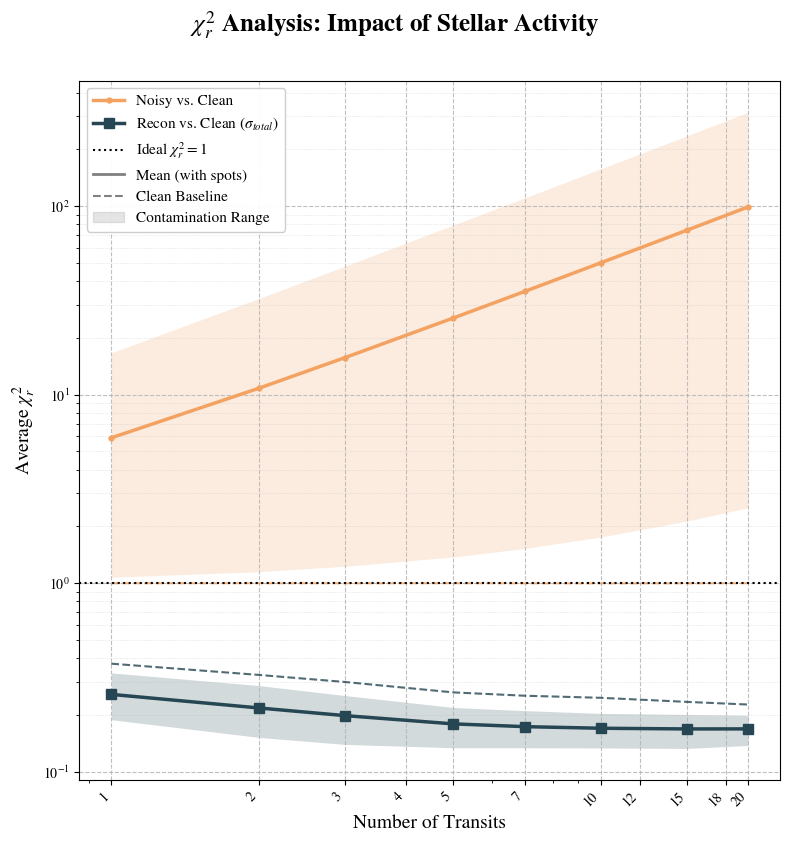

In [37]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from matplotlib.lines import Line2D

# ============================
# 1. Configuración y Carga
# ============================
filename = 'results_by_transits_final.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    # Generamos datos dummy si no existe el archivo para que el código sea testeable
    print(f"Advertencia: '{filename}' no encontrado. Usando datos simulados para demostración.")
    all_results = {}
    transits_dummy = [1, 2, 3, 5, 7, 10, 15, 20]
    
    # Caso Base (Clean)
    all_results[(0.0, 0.0)] = {
        'n_transits': transits_dummy,
        'chi2r_noisy_clean_inst': [1.0] * 8,
        'chi2r_recon_clean_total': [0.5 * (t**-0.1) for t in transits_dummy]
    }
    # Casos Contaminados (Simulados)
    for i in range(10):
        noise = np.random.normal(0, 0.05, 8)
        offset = np.random.uniform(0.1, 0.5)
        all_results[(0.01*(i+1), 0.01*(i+1))] = {
            'n_transits': transits_dummy,
            'chi2r_noisy_clean_inst': [1.0 + offset + n + (t/100) for n, t in zip(noise, transits_dummy)],
            'chi2r_recon_clean_total': [0.5 * (t**-0.1) + offset/2 + n for n, t in zip(noise, transits_dummy)]
        }

# Definir la llave del caso base
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)

if case_base is None:
    raise RuntimeError("No se encontraron datos para el caso base (f_spot=0, f_fac=0).")

# Extraer eje X
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# 2. Estilos y Métricas
# ============================
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_total'
]

labels_metric = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# Colores definidos
palette = {
    'chi2r_noisy_clean_inst':  "#F4A261", # Naranja
    'chi2r_recon_clean_total': "#264653", # Azul oscuro
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_total': 's',
}

# ============================
# 3. Plot Principal
# ============================
fig, ax = plt.subplots(1, 1, figsize=(8, 9)) # Un poco más ancho para que respire

fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')

for metric in metrics:
    color = palette[metric]
    marker = markers[metric]
    
    # --- A. Calcular Estadísticas (Min, Max, Mean) de casos Contaminados ---
    mins, maxs, means = [], [], []
    
    for nt in transits_plot:
        vals = []
        # Recorremos todos los escenarios EXCEPTO el base
        for key, data in all_results.items():
            if key == base_key: continue 
            
            if nt in data['n_transits']:
                idx = data['n_transits'].index(nt)
                val = data[metric][idx]
                if np.isfinite(val):
                    vals.append(val)
        
        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
            means.append(np.mean(vals))
        else:
            mins.append(np.nan); maxs.append(np.nan); means.append(np.nan)

    # --- B. Plotear Sombra (Rango de contaminación) ---
    ax.fill_between(transits_plot, mins, maxs, 
                    color=color, alpha=0.2, lw=0)

    # --- C. Plotear Promedio Contaminado (Línea Sólida) ---
    ax.plot(transits_plot, means, 
            marker=marker, markersize=7,
            color=color, lw=2.5, linestyle='-',
            label=labels_metric[metric]) # Etiqueta principal para el color

    # --- D. Plotear Baseline "Clean" (Línea Punteada) ---
    # Extraemos datos del caso base
    y_base = []
    for nt in transits_plot:
        if nt in case_base['n_transits']:
            y_base.append(case_base[metric][case_base['n_transits'].index(nt)])
        else:
            y_base.append(np.nan)
            
    # La dibujamos del mismo color pero punteada y ligeramente transparente
    ax.plot(transits_plot, y_base, 
            color=color, lw=1.5, linestyle='--', alpha=0.8)

# ============================
# 4. Configuración de Ejes (Ticks aumentados)
# ============================
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)

# --- EJE X: Ticks manuales para rellenar huecos visuales ---
# Tus datos + intermedios (4, 6, 8, 9, 12, 18)
custom_ticks = sorted(list(set(transits_plot) | {4, 12, 18}))
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter()) # Números normales (no 10^1)
ax.ticklabel_format(axis='x', style='plain') # Evita notación científica forzada
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# --- EJE Y: Subdivisiones logarítmicas tupidas ---
# Pone rayitas en 0.2, 0.3... 2, 3, 4... etc
locmin = ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), numticks=12)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(ticker.NullFormatter()) # Solo rayitas, sin números

# Grilla
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.8)
ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.5)

# Línea de referencia ideal
ax.axhline(1, color='black', linestyle=':', lw=1.5, label=r'Ideal $\chi^2_r = 1$')

# ============================
# 5. Leyenda Personalizada
# ============================
handles, labels_ax = ax.get_legend_handles_labels()

# Crear sección explicativa de estilos
# Línea Sólida
handles.append(Line2D([0], [0], color='gray', linestyle='-', lw=2))
labels_ax.append('Mean (with spots)')

# Línea Punteada
handles.append(Line2D([0], [0], color='gray', linestyle='--', lw=1.5))
labels_ax.append('Clean Baseline')

# Sombra
handles.append(plt.Rectangle((0,0),1,1, color='gray', alpha=0.2))
labels_ax.append('Contamination Range')

# Ordenar leyenda: Primero métricas, luego referencia, luego explicación de estilos
ax.legend(handles=handles, labels=labels_ax, fontsize=11, loc='upper left', framealpha=0.95)

# ============================
# 6. Guardar
# ============================
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_final_02.png'), dpi=300)
plt.show()